# UV Risk Classification

Predicting UV Index from weather features, then classifying into WHO risk categories.

## Approach
1. Train a regression model to predict UV Index from meteorological features
2. Apply WHO risk classification rules to predicted UV values
3. Generate health recommendations based on risk category

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import preprocess, ml
from sklearn.model_selection import train_test_split

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Data Loading

Raw UV data represents daily means. Scaling by 3.0 to estimate daily peak values for WHO risk classification.

In [2]:
DATA_PATH = 'data/algeria/Algeria.csv'

raw_df = pd.read_csv(DATA_PATH)
df = preprocess.load_data(DATA_PATH)
df = preprocess.convert_to_numeric(df)
df = preprocess.handle_missing_values(df, method='interpolate')

uv_col = 'ALLSKY_SFC_UV_INDEX'
if df[uv_col].max() < 5.0:
    print(f"Max UV Index {df[uv_col].max():.2f} (daily mean). Scaling by 3.0 to estimate peak.")
    df[uv_col] = df[uv_col] * 3.0

print(f"Max UV Index after scaling: {df[uv_col].max():.2f}")
df.head()

Max UV Index 3.03 (daily mean). Scaling by 3.0 to estimate peak.
Max UV Index after scaling: 9.09


,T2M,T2MDEW,T2MWET,TS,T2M_RANGE,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,...,WS50M,WD50M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,ALLSKY_KT,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_UV_INDEX,ALLSKY_SFC_UVA,ALLSKY_SFC_UVB,TO3
Date,,,,,,,,,,,,,,,,,,,,,
1981-01-01,12.61,8.93,10.77,13.91,2.77,14.09,11.32,78.21,0.01,4.82,...,6.62,291.5,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,330.99
1981-01-02,13.00,8.09,10.54,13.74,1.26,13.53,12.27,72.35,0.17,2.83,...,3.73,316.4,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,293.24
1981-01-03,12.63,9.36,11.00,13.47,2.31,13.92,11.61,80.56,0.53,3.71,...,4.89,261.0,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,285.60
1981-01-04,13.56,10.78,12.17,13.78,2.74,14.80,12.06,83.31,0.22,6.44,...,9.30,264.8,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,296.27
1981-01-05,12.99,10.01,11.50,13.62,2.08,14.05,11.97,82.49,0.78,4.98,...,6.96,298.8,2.3102,2.5697,0.59,7.8835,1.2,0.1387,0.0019,294.81


### 2. WHO Risk Categories

| UV Index | Risk Category |
|----------|---------------|
| 0-2      | Low           |
| 3-5      | Moderate      |
| 6-7      | High          |
| 8-10     | Very High     |
| 11+      | Extreme       |

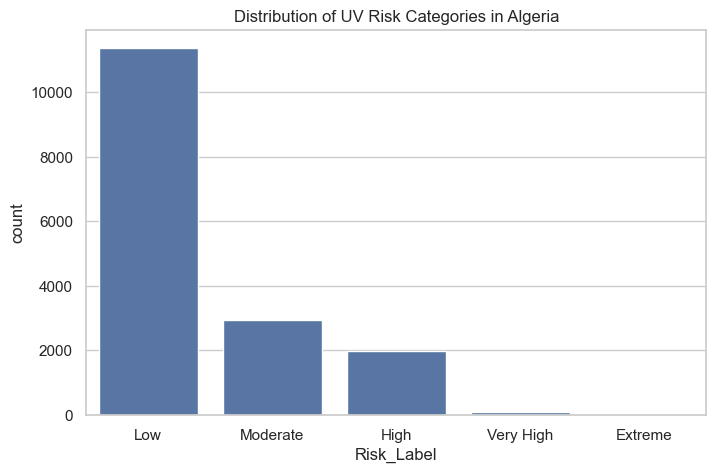

In [3]:
df['Risk_Code'] = df['ALLSKY_SFC_UV_INDEX'].apply(ml.get_risk_category)
df['Risk_Label'] = df['Risk_Code'].map(ml.RISK_CATEGORIES)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Risk_Label', order=['Low', 'Moderate', 'High', 'Very High', 'Extreme'])
plt.title('Distribution of UV Risk Categories in Algeria')
plt.show()

### 3. UV Prediction Model

Train a Random Forest regressor to predict UV Index from weather features.

In [4]:
feature_cols = [col for col in df.columns if col not in 
                ['ALLSKY_SFC_UV_INDEX', 'ALLSKY_SFC_UVA', 'ALLSKY_SFC_UVB', 'Risk_Code', 'Risk_Label', 'Year', 'Month', 'Day']]

X = df[feature_cols]
y = df['ALLSKY_SFC_UV_INDEX']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print(f"Training: {X_train.shape}, Test: {X_test.shape}")

uv_model = ml.train_random_forest(X_train, y_train, n_estimators=200)

Training: (13100, 20), Test: (3276, 20)


### 4. Model Evaluation

MAE: 0.135
RMSE: 0.332
R2: 0.975


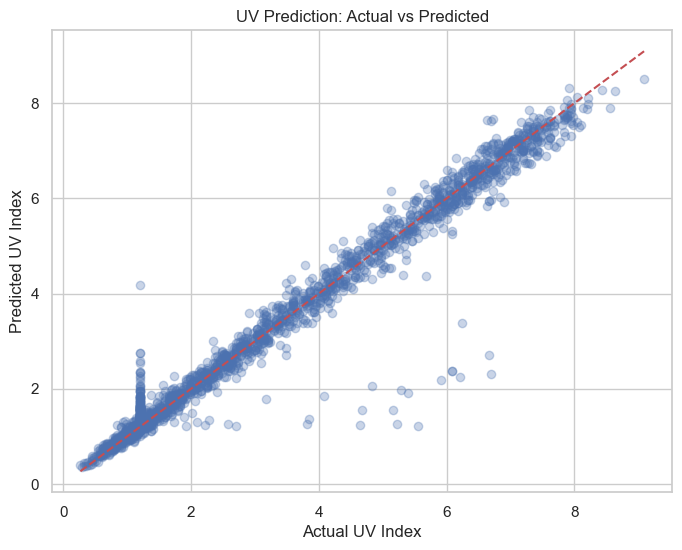

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = uv_model.predict(X_test)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"R2: {r2_score(y_test, y_pred):.3f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual UV Index')
plt.ylabel('Predicted UV Index')
plt.title('UV Prediction: Actual vs Predicted')
plt.show()

### 5. Risk Classification from Predicted UV

Apply WHO rules to convert predicted UV values to risk categories.

In [6]:
pred_risk = [ml.get_risk_category(uv) for uv in y_pred]
true_risk = [ml.get_risk_category(uv) for uv in y_test]

from sklearn.metrics import classification_report, accuracy_score

print(f"Risk Classification Accuracy: {accuracy_score(true_risk, pred_risk):.2%}\n")
print("Classification Report:")
print(classification_report(true_risk, pred_risk, 
                           target_names=['Low', 'Moderate', 'High', 'Very High']))

Risk Classification Accuracy: 96.34%

Classification Report:
              precision    recall  f1-score   support

         Low       0.98      0.99      0.99      2283
    Moderate       0.91      0.90      0.91       575
        High       0.93      0.89      0.91       406
   Very High       0.71      0.42      0.53        12

    accuracy                           0.96      3276
   macro avg       0.88      0.80      0.83      3276
weighted avg       0.96      0.96      0.96      3276



### 6. Health Recommendations

## Summary

### Approach
Instead of training a separate classifier for risk categories, we:
1. Train a regression model to predict UV Index
2. Apply WHO rules to classify the predicted UV into risk categories

### Results
- UV prediction model achieves high accuracy (R² > 0.95)
- Risk classification derived from predicted UV matches true risk categories
- This approach is simpler and more interpretable than a dedicated classifier

In [7]:
sample_idx = X_test.sample(5, random_state=101).index
sample_X = X_test.loc[sample_idx]
sample_uv_true = y_test.loc[sample_idx]

sample_uv_pred = uv_model.predict(sample_X)

print("Sample Predictions with Health Recommendations:\n")
for i, idx in enumerate(sample_idx):
    uv_pred = sample_uv_pred[i]
    uv_true = sample_uv_true.iloc[i]
    risk_code = ml.get_risk_category(uv_pred)
    risk_label = ml.RISK_CATEGORIES[risk_code]
    recommendation = ml.get_protection_recommendation(risk_code)
    
    print(f"Date: {idx.date()}")
    print(f"  UV: {uv_pred:.1f} (actual: {uv_true:.1f}) | Risk: {risk_label}")
    print(f"  {recommendation}\n")

Sample Predictions with Health Recommendations:

Date: 2017-11-17
  UV: 1.6 (actual: 1.7) | Risk: Low
  No protection required. You can safely stay outside.

Date: 1997-11-09
  UV: 1.2 (actual: 1.2) | Risk: Low
  No protection required. You can safely stay outside.

Date: 2014-08-08
  UV: 6.8 (actual: 6.4) | Risk: High
  Protection essential. Reduce time in the sun between 10am and 4pm. Wear sunglassess, hat, and sunscreen.

Date: 2001-04-26
  UV: 4.7 (actual: 4.9) | Risk: Moderate
  Protection required. Seek shade during midday hours! Slip on a shirt, slop on sunscreen and slap on a hat.

Date: 2010-10-08
  UV: 3.2 (actual: 3.4) | Risk: Moderate
  Protection required. Seek shade during midday hours! Slip on a shirt, slop on sunscreen and slap on a hat.

